# Phase 1 — Reddit Engagement Analysis

## Objective & Research Questions

**RQ1 (Supervised):** Can we predict **high engagement** (score ≥ 80th percentile) from content and structural features?
- **Features:** title length, selftext presence, subreddit, post type, time of day

**RQ2 (Unsupervised):** Can we discover natural clusters of Reddit submissions based on engagement patterns, subreddit, and content structure  **without using the score label**?
- **Features:** subreddit, content structure (title length, selftext presence), post type, time of day


#### 1. Prerequisite

1. Import all packages

#### Datasets
- Reddit comments/submissions 2026-01: https://academictorrents.com/details/8412b89151101d88c915334c45d9c223169a1a60
- Access dataset: https://transmissionbt.com/

---


In [ ]:
import zstandard as zstd
import json
import io
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset path 
INPUT_FILE = "../Dataset/reddit_subset.jsonl"

### 1.1 Data Retrieval (Document Sources; Programmatic Retrieval; Challenges; Raw Storage)

**Document sources:**
- **Primary source:** Reddit submissions (January 2026) from [Academic Torrents](https://academictorrents.com/details/8412b89151101d88c915334c45d9c223169a1a60) (Pushshift/Reddit data dump).
- **Access method:** BitTorrent client (e.g., [Transmission](https://transmissionbt.com/)) to download the compressed `RS_2026-01.zst` file (~19.6 GB).

**Programmatic retrieval:**
- We use **file-based extraction** (not SQL/API): Python `zstandard` library decompresses the `.zst` archive and streams JSONL lines.
- Each line is one submission. We parse `json.loads()`, filter NSFW, and write non-NSFW rows until we reach a 2 GB subset.

**Handle challenges:**
- **Rate limits:** N/A — torrent + local file reading; no external API calls.
- **Auth:** N/A — data is public; no credentials required.
- **Data quality:** We filter out `over_18` submissions during extraction. Invalid JSON lines are skipped via `try/except`.

**Store raw data:**
- Output file: `reddit_subset.jsonl` (~2 GB). Each line is one JSON object (one Reddit submission). Preserves all original fields for reproducibility.

**NO NEED TO RUN AGAIN**

In [10]:
# INPUT_FILE = "RS_2026-01.zst"
# OUTPUT_FILE = "reddit_subset.jsonl"
# TARGET_SIZE = 2 * 1024**3  # 2GB

# written_bytes = 0

# with open(INPUT_FILE, "rb") as fh:
#     dctx = zstd.ZstdDecompressor()
#     with dctx.stream_reader(fh) as reader:
#         text_stream = io.TextIOWrapper(reader, encoding="utf-8", errors="replace")

#         with open(OUTPUT_FILE, "wb") as out:
#             for line in tqdm(text_stream, desc="Extracting"):
#                 try:
#                     obj = json.loads(line)

#                     # Remove only NSFW
#                     if obj.get("over_18"):
#                         continue

#                     json_line = (json.dumps(obj, ensure_ascii=False) + "\n").encode("utf-8")
#                     out.write(json_line)

#                     written_bytes += len(json_line)

#                     if written_bytes >= TARGET_SIZE:
#                         break

#                 except Exception:
#                     continue

# print("Done! Extracted ~2GB subset.")
# print(f"Total written: {written_bytes / (1024**3):.2f} GB")

---

## 2. Wrangling & Cleaning

This section performs an **initial audit** (missing values, duplicates, outliers) and applies a **reproducible cleaning pipeline**. We use `quantDDA()` and `vizDDA()` from Lab 2 for quantitative and visual data quality checks.

### 2.1 Initial Audit (Missing, Duplicates, Outliers)

In [11]:
def audit_dataframe(df):
    """Initial audit: missing values, duplicates, basic outlier context."""
    return {
        "shape": df.shape,
        "missing": df.isnull().sum().sort_values(ascending=False),
        "missing_pct": (df.isnull().mean() * 100).round(2).sort_values(ascending=False),
        "duplicate_ids": df["id"].duplicated().sum() if "id" in df.columns else 0,
    }

df = pd.read_json(INPUT_FILE, lines=True)
audit = audit_dataframe(df)
print("Shape:", audit["shape"])
print("\n=== TOP MISSING VALUES ===")
print(audit["missing"].head(20))
print("\n=== DUPLICATES ===")
print("Duplicate IDs:", audit["duplicate_ids"])

print("\n=== SCORE DESCRIBE ===")
print(df["score"].describe())

print("\n=== SCORE QUANTILES ===")
print(df["score"].quantile([0.5, 0.75, 0.8, 0.9, 0.95]))

Shape: (476600, 152)

=== TOP MISSING VALUES ===
removed_by                  476600
ad_user_targeting           476600
banned_by                   476600
ad_promoted_user_posts      476600
priority_id                 476600
ad_supplementary_text_md    476600
likes                       476600
original_link               476600
adserver_click_url          476600
embed_url                   476600
discussion_type             476600
adserver_imp_pixel          476600
app_store_data              476600
impression_id_str           476600
impression_id               476600
campaign_id                 476600
banned_at_utc               476600
promo_layout                476600
ad_business                 476600
promoted_by                 476600
dtype: int64

=== DUPLICATES ===
Duplicate IDs: 0

=== SCORE DESCRIBE ===
count    476600.000000
mean         58.379020
std         752.728831
min           0.000000
25%           1.000000
50%           1.000000
75%          10.000000
max      169757.

---

### 2.2 Reproducible Cleaning Pipeline (RQ1 & RQ2)

High engagement = score ≥ 80th percentile. Defines `clean_reddit_data()` with feature engineering:
- **RQ1:** `title_length`, `has_selftext`, `subreddit`, `post_type`, `hour_of_day`, `day_of_week` → predict `high_engagement`
- **RQ2:** Same features (no score) → clustering on content structure and engagement patterns


In [12]:
# Reproducible pipeline: features aligned with RQ1 (supervised) and RQ2 (unsupervised)
def clean_reddit_data(raw_path_or_df, engagement_quantile: float = 0.8) -> pd.DataFrame:
    """Load → select → derive target → engineer RQ1/RQ2 features → handle missing → drop dups."""
    df_raw = pd.read_json(raw_path_or_df, lines=True) if isinstance(raw_path_or_df, str) else raw_path_or_df.copy()
    model_columns = ["id", "title", "selftext", "score", "subreddit", "created_utc", "is_self", "domain"]
    df = df_raw[[c for c in model_columns if c in df_raw.columns]].copy()

    # Target for RQ1 (supervised)
    threshold = df["score"].quantile(engagement_quantile)
    df["high_engagement"] = (df["score"] >= threshold).astype(int)

    # RQ1 & RQ2: Content & structural features (no score used for RQ2)
    df["title_length"] = df["title"].fillna("").str.len()
    df["has_selftext"] = (df["selftext"].fillna("").str.strip() != "").astype(int)
    df["post_type"] = df["is_self"].map({True: "self", False: "link"})
    dt = pd.to_datetime(df["created_utc"], unit="s", utc=True)
    df["hour_of_day"] = dt.dt.hour
    df["day_of_week"] = dt.dt.dayofweek  # 0=Mon, 6=Sun

    # Handle missing
    if "domain" in df.columns:
        df["domain"] = df["domain"].fillna("").replace("", "[unknown]")
    if "id" in df.columns:
        df = df.drop_duplicates(subset=["id"], keep="first")
    return df

df_model = clean_reddit_data(df)
threshold = df_model["score"].quantile(0.8)
print("Cleaned shape:", df_model.shape)
print("High engagement threshold (80th %):", threshold)
print("Target distribution:", df_model["high_engagement"].value_counts(normalize=True).to_dict())
print("Columns:", df_model.columns.tolist())

Cleaned shape: (476600, 14)
High engagement threshold (80th %): 17.0
Target distribution: {0: 0.7967016365925305, 1: 0.20329836340746957}
Columns: ['id', 'title', 'selftext', 'score', 'subreddit', 'created_utc', 'is_self', 'domain', 'high_engagement', 'title_length', 'has_selftext', 'post_type', 'hour_of_day', 'day_of_week']


### 2.3 quantDDA() and vizDDA() (from Lab 2)

We use the `quantDDA()` and `vizDDA()` functions from Lab 2 for quantitative and visual data quality checks. `quantDDA` reports missing values, outliers (IQR), skewness, kurtosis; `vizDDA` produces histograms, scatter plots, boxplots, and heatmaps.

In [13]:
def quantDDA(df):
    summary_list = []  # List to store summary dictionaries

    for col in df.columns:  # Loop through each column in the DataFrame
        series = df[col]  
        
        # Basic counts (for all features)
        n_obs = len(series)                     # Total number of observations (rows)
        n_entries = series.count()              # Number of non-missing values (entries)
        n_unique = series.nunique(dropna=True)  # Number of unique non-missing values
        n_missing = series.isna().sum()         # Number of missing (NaN) values

        # Mode(s): most frequent value(s)
        if n_unique == n_entries:  
            modes = "No mode (all values unique)"  # No mode if every value appears once
        else:
            modes = series.dropna().mode().tolist()  # Most frequent value(s), ignoring NaN
            
        # Dictionary with universal statistics
        summary = {
            "Feature": col,                     # Feature (column) name
            "Observations": int(n_obs),         # Total observations in the dataset
            "Entries": int(n_entries),          # Non-missing values in this feature
            "Unique": int(n_unique),            # Unique values count
            "Missing": int(n_missing),          # Missing values count
            "Mode(s)": modes                    # Most common value(s)
        }

        # Compute numeric statistics only for numeric columns
        if pd.api.types.is_numeric_dtype(series):   # Check if column contains numbers
            clean = series.dropna()                 # Remove missing values

            if len(clean) > 0:                      # Only compute if column is not empty

                # Quartiles
                q1 = clean.quantile(0.25)           # First quartile (25th percentile)
                q2 = clean.quantile(0.50)           # Median (50th percentile)
                q3 = clean.quantile(0.75)           # Third quartile (75th percentile)

                # IQR Outlier bounds
                iqr = q3 - q1                       # Interquartile range
                lower = q1 - 1.5 * iqr              # Lower outlier boundary
                upper = q3 + 1.5 * iqr              # Upper outlier boundary

                # Extreme value thresholds (top/bottom 1%)
                lower_ext = clean.quantile(0.01)    # Bottom 1% threshold
                upper_ext = clean.quantile(0.99)    # Top 1% threshold

                # Update dictionary with numeric-only stats
                summary.update({
                    "Mean": clean.mean(),           # Average value
                    "Standard Deviation": clean.std(),             # Standard deviation
                    "Minimum": clean.min(),             # Minimum value
                    "Maximum": clean.max(),             # Maximum value
                    "First Quartile": q1,                       # 25th percentile
                    "Median": q2,              # Median (50th percentile)
                    "Third Quartile": q3,                       # 75th percentile
                    "Skewness": clean.skew() if len(clean) > 2 else np.nan,                     #  Measures distribution asymmetry
                    "Kurtosis": clean.kurt() if len(clean) > 3 else np.nan,                     # Measures tail heaviness / peakedness
                    "Outliers": int(((clean < lower) | (clean > upper)).sum()),                 # Values outside IQR boundaries
                    "Extreme (1%)": int(((clean <= lower_ext) | (clean >= upper_ext)).sum())    # Values in top/bottom 1% of distribution
                })

        summary_list.append(summary) 

    return pd.DataFrame(summary_list)


In [14]:
# Audit RQ1/RQ2 numeric features
cols_for_audit = ["score", "high_engagement", "title_length", "has_selftext", "hour_of_day", "day_of_week"]
cols_for_audit = [c for c in cols_for_audit if c in df_model.columns]
quant_summary = quantDDA(df_model[cols_for_audit])
quant_summary

,Feature,Observations,Entries,Unique,Missing,Mode(s),Mean,Standard Deviation,Minimum,Maximum,First Quartile,Median,Third Quartile,Skewness,Kurtosis,Outliers,Extreme (1%)
0,score,476600,476600,3424,0,[1],58.379020,752.728831,0,169757,1.0,1.0,10.0,81.901940,11321.392931,81930,50091
1,high_engagement,476600,476600,2,0,[0],0.203298,0.402453,0,1,0.0,0.0,0.0,1.474472,0.174068,96892,476600
2,title_length,476600,476600,300,0,[33],45.545332,36.971575,1,300,22.0,36.0,58.0,2.649650,11.057404,21795,11559
3,has_selftext,476600,476600,2,0,[1],0.657547,0.474531,0,1,0.0,1.0,1.0,-0.664016,-1.559090,0,476600
4,hour_of_day,476600,476600,18,0,[16],8.793640,5.467555,0,17,4.0,9.0,14.0,-0.091239,-1.348873,0,57692
5,day_of_week,476600,476600,1,0,[3],3.000000,0.000000,3,3,3.0,3.0,3.0,0.000000,0.000000,0,476600


In [15]:
def vizDDA(name, df):
    print(f"\n{'=' * 80}\n{name}\n{'=' * 80}")

    df_plot = df.copy()

    max_unique = 10  # Set to 500 to see all columns. Set to 10 for visual purposes (only low-cardinality categorical). Adjust as needed.

    def safe_nunique(s):
        try:
            return s.nunique(dropna=True)
        except (TypeError, ValueError):
            return float('inf')  # Skip columns with unhashable types

    keep_cols = [
        col for col in df_plot.columns
        if pd.api.types.is_numeric_dtype(df_plot[col]) or safe_nunique(df_plot[col]) <= max_unique
    ]  # Keep numeric always + only low-cardinality categorical

    df_plot = df_plot[keep_cols]  # Filter df for readable plotting

    cols = df_plot.columns.tolist()  # Column names used in grid
    n = len(cols)  # Grid size (n x n)

    numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()  # Numeric columns
    categorical_cols = [c for c in cols if c not in numeric_cols]  # Categorical columns (low-cardinality)

    print("Columns used in grid:", cols)

    fig, axes = plt.subplots(n, n, figsize=(4 * n, 4 * n))  # Create plot grid
    if n == 1:
        axes = np.array([[axes]]) 

    # Loop through grid
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]  # Current subplot
            row_var = cols[i]  # Y variable
            col_var = cols[j]  # X variable

            # Matrix headers 
            if i == 0:
                ax.set_title(col_var)  # Column headers
            if j == 0:
                ax.set_ylabel(row_var)  # Row headers
            else:
                ax.set_ylabel("")  # Reduce clutter

            if i != n - 1:
                ax.set_xlabel("")  # Hide x-label except bottom row

            # Diagonal: Univariate
            if i == j:
                if row_var in numeric_cols:
                    df_plot[row_var].dropna().hist(ax=ax, bins=30, edgecolor="black")
                    cell_label = f"{row_var} (hist)"  # Cell meaning
                else:
                    df_plot[row_var].value_counts().plot(kind="bar", ax=ax)
                    ax.tick_params(axis="x", rotation=45)
                    cell_label = f"{row_var} (bar)"  # Cell meaning

            # Off-diagonal: Bivariate
            else:
                # Numeric vs Numeric -> Scatter
                if row_var in numeric_cols and col_var in numeric_cols:
                    ax.scatter(df_plot[col_var], df_plot[row_var], alpha=0.5, s=15)
                    cell_label = f"{row_var} vs {col_var} (scatter)"  # Cell meaning

                # Numeric vs Categorical -> Boxplot
                elif row_var in numeric_cols and col_var in categorical_cols:
                    sns.boxplot(x=df_plot[col_var], y=df_plot[row_var], ax=ax)
                    ax.tick_params(axis="x", rotation=45)
                    cell_label = f"{row_var} by {col_var} (box)"  # Cell meaning

                # Categorical vs Numeric -> Boxplot (variables flipped)
                elif row_var in categorical_cols and col_var in numeric_cols:
                    sns.boxplot(x=df_plot[row_var], y=df_plot[col_var], ax=ax)
                    ax.tick_params(axis="x", rotation=45)
                    cell_label = f"{col_var} by {row_var} (box)"  # Cell meaning

                # Categorical vs Categorical -> Heatmap
                else:
                    ct = pd.crosstab(df_plot[row_var], df_plot[col_var])
                    sns.heatmap(
                        ct,
                        annot=True,
                        fmt="d",
                        cbar=False,
                        ax=ax,
                        annot_kws={"color": "white"}  # Heatmap numbers in white
                    )
                    ax.tick_params(axis="x", rotation=45)
                    cell_label = f"{row_var} x {col_var} (count)"  # Cell meaning

            # Labeling
            ax.text(
                0.02, 0.95, cell_label,  # Position inside axes (top-left)
                transform=ax.transAxes,
                fontsize=9,
                va="top",
                ha="left",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none") # styling
            )

    plt.tight_layout()
    plt.show()

    # Missing values heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_plot.isna(), cbar=False)
    plt.title("Missing Values Heatmap")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()


**Visual EDA:** `vizDDA` grid below.


Reddit Model Subset (RQ1/RQ2 features):
Columns used in grid: ['score', 'high_engagement', 'title_length', 'has_selftext', 'hour_of_day', 'post_type', 'subreddit_top']


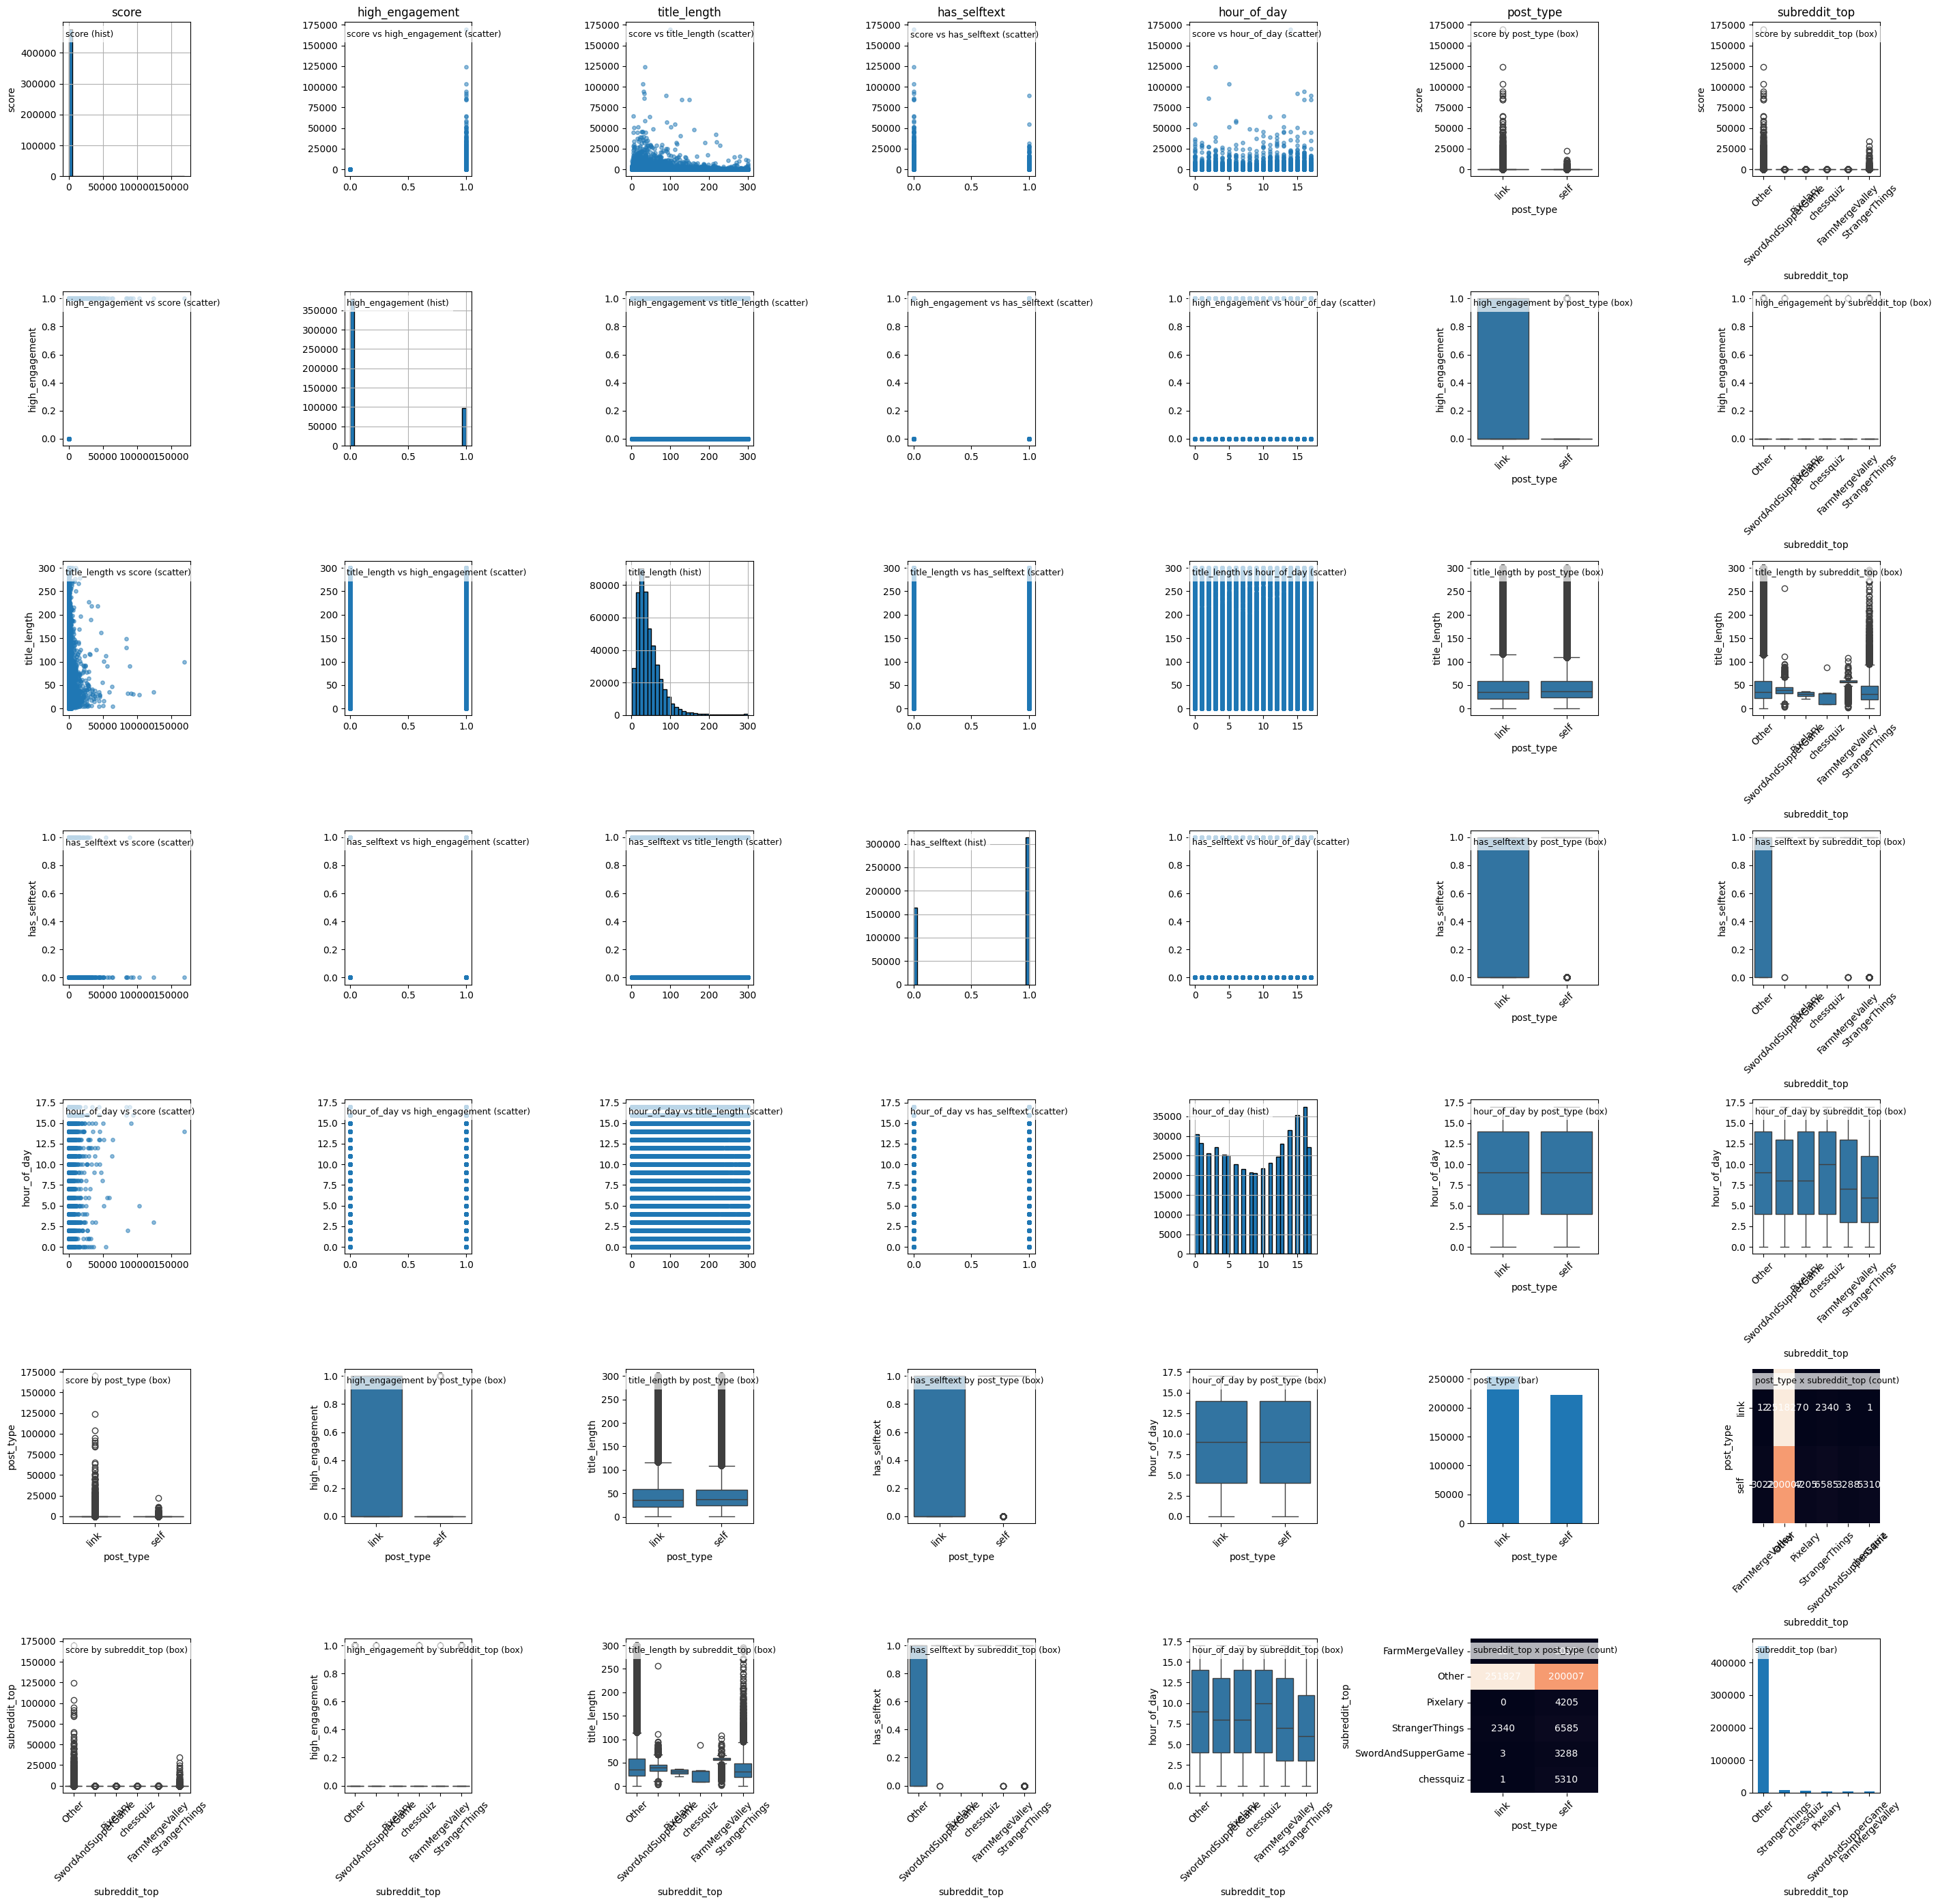

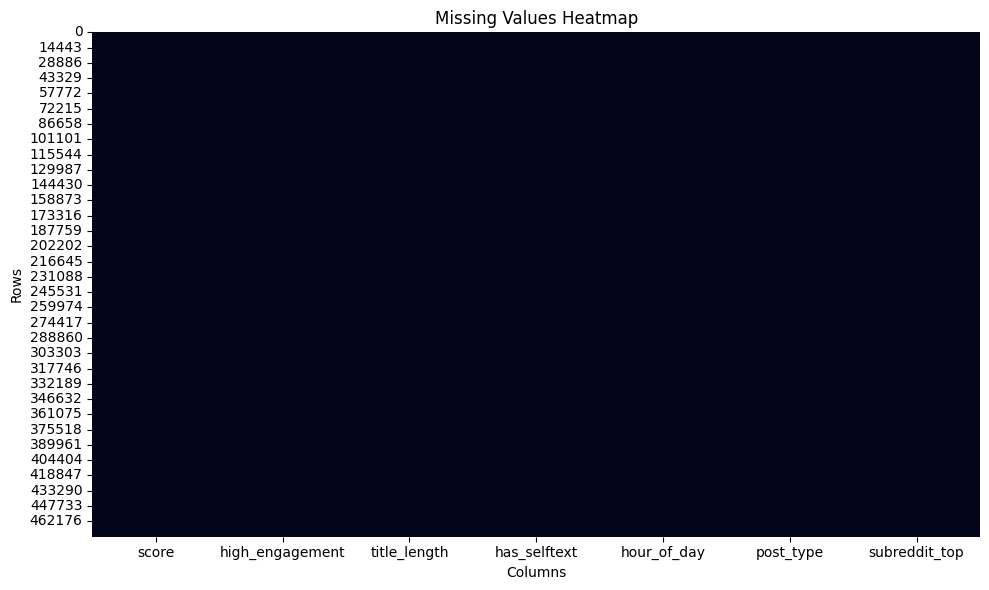

In [16]:
# Viz subset: RQ1/RQ2 features (numeric + low-cardinality categorical)
viz_cols = ["score", "high_engagement", "title_length", "has_selftext", "hour_of_day", "post_type"]
df_viz = df_model[[c for c in viz_cols if c in df_model.columns]].copy()
top_subs = df_model["subreddit"].value_counts().head(5).index.tolist()
df_viz["subreddit_top"] = df_model["subreddit"].apply(lambda x: x if x in top_subs else "Other")
vizDDA("Reddit Model Subset (RQ1/RQ2 features):", df_viz)

# 3. Exploratory Data Analysis (EDA)

## 3.1 Purpose

After completing data retrieval and cleaning, we now explore the dataset to better understand its structure before implementing any predictive models.

The objectives of this EDA are to:

- Examine the statistical properties of the engineered features  
- Analyze how structural attributes relate to engagement  
- Assess the balance of the target variable  
- Identify patterns that may support both supervised and unsupervised learning  

All variables analyzed in this section were generated in `clean_reddit_data()` and are aligned with the research questions defined earlier.

---

## 3.2 Summary Statistics

Using `quantDDA()`, we computed descriptive statistics for the main modeling variables:

- `score`
- `high_engagement`
- `title_length`
- `has_selftext`
- `hour_of_day`
- `day_of_week`

The dataset contains **476,600 submissions**, and no missing values were found in the selected model features. This confirms that the cleaning pipeline successfully produced a modeling-ready dataset.

### Score Distribution (Context)

From the audit results:

- Median score = 1  
- 75th percentile = 10  
- 80th percentile ≈ 17  
- 95th percentile = 163  
- Maximum score = 169,757  

The distribution of scores is extremely right-skewed. Most posts receive minimal engagement, while a small number receive very high scores. This heavy-tailed behavior is typical of online content platforms and supports the decision to define high engagement using a percentile-based threshold rather than a fixed value.

---

## 3.3 Target Variable Distribution

The binary target `high_engagement` labels posts above the 80th percentile as 1.

As expected:

- Approximately 20% of posts are labeled high engagement  
- Approximately 80% are labeled low engagement  

This introduces moderate class imbalance. While not extreme, it suggests that evaluation metrics such as precision, recall, and F1-score will be more informative than accuracy alone in Phase 2.

---

## 3.4 Univariate Analysis

We use `vizDDA()` to examine the distribution of individual features.

### Title Length

Title length exhibits noticeable variability, with a right-skewed distribution. Most titles are relatively short, but there is a long tail of longer titles.

This variability indicates that title length meaningfully differentiates posts and may capture differences in content detail or intent.

---

### Has Selftext

`has_selftext` is a binary indicator of whether a post includes body text.

This variable separates link-style posts from discussion-style posts. Since format influences how users interact with content, this structural distinction may play an important role in predicting engagement.

---

### Post Type

Post type (`self` vs `link`) reinforces the structural distinction between content formats.

Differences in engagement patterns across formats suggest that user behavior may vary depending on whether a post invites discussion or redirects users to external content.

---

### Hour of Day

Posting activity is not uniformly distributed across all hours. Some hours show significantly higher activity levels.

This suggests that user engagement on Reddit follows daily behavioral cycles. Time-of-day may therefore contribute predictive value.

---

### Day of Week

Although weekly variation appears less pronounced than daily variation, the inclusion of `day_of_week` allows the model to capture potential cyclical engagement patterns.

---

## 3.5 Bivariate Analysis

We now examine how structural features relate to engagement.

### Title Length vs High Engagement

Boxplots indicate that high-engagement posts show slightly greater variability in title length. While there is substantial overlap between classes, longer titles appear somewhat more frequently among high-engagement posts.

This suggests that title length alone is not a strong discriminator, but may contribute predictive signal when combined with other features.

---

### Has Selftext vs Engagement

Engagement rates differ between posts with and without selftext. Posts containing selftext appear to follow different engagement patterns than link-only posts.

This supports the hypothesis that content format influences user interaction.

---

### Post Type vs Engagement

Differences between self and link posts are also reflected in engagement distributions. This reinforces the importance of structural features in modeling engagement.

---

### Subreddit vs Engagement

Grouping the top subreddits reveals noticeable variation in engagement rates across communities.

This suggests that subreddit context captures community-level effects such as audience size, norms, and activity levels. Subreddit is therefore likely to be one of the strongest predictors for RQ1 and a key variable in clustering for RQ2.

---

## 3.6 Correlation Analysis

To assess relationships among numeric predictors, we computed the correlation matrix for:

- `score`
- `title_length`
- `hour_of_day`
- `day_of_week`

The correlations between structural features are generally weak.

This indicates:

- Low multicollinearity among predictors  
- Each feature contributes relatively independent information  
- Engagement behavior is unlikely to be explained by simple linear relationships alone  

This supports the use of classification models that can capture nonlinear interactions in Phase 2.

---

## 3.7 Data Quality Confirmation

The missing values heatmap generated by `vizDDA()` shows no missing values in the selected modeling variables.

This confirms that the cleaning pipeline successfully handled missing data and that no additional preprocessing is required before baseline modeling.

---

## 3.8 Summary of Insights

From this exploratory analysis:

1. Engagement is intentionally imbalanced (~20% high engagement).  
2. Score distribution is highly skewed, validating percentile-based thresholding.  
3. Structural features (title length, selftext presence, post type) show meaningful variability.  
4. Temporal features capture daily behavioral patterns.  
5. Subreddit appears to strongly influence engagement.  
6. Numeric predictors exhibit low correlation, reducing concerns about redundancy.  

Overall, the dataset demonstrates sufficient structure and variability to support both:

- Binary classification (RQ1)  
- Clustering based on structural attributes (RQ2)  

This EDA provides a clear foundation for implementing and evaluating the baseline model in the next section.

---
## 5. Report

### Brief Summary of Work (Sections 1 & 2)

**1. Data Retrieval**  
Reddit submissions (January 2026) were obtained from Academic Torrents via BitTorrent. A 2 GB subset was extracted from the compressed `.zst` archive using Python's `zstandard` library: each line was parsed as JSON, NSFW posts (`over_18`) were filtered out, and valid rows were written to `reddit_subset.jsonl`. No API rate limits or authentication were required. Raw data is stored as one JSON object per line for reproducibility.

**2. Wrangling & Cleaning**  
An initial audit using `audit_dataframe()` summarised shape (476,600 × 152), missing values, and duplicate IDs (0). A reproducible pipeline, `clean_reddit_data()`, was implemented to: select model columns; derive the target `high_engagement` (score ≥ 80th percentile); engineer RQ features (`title_length`, `has_selftext`, `post_type`, `hour_of_day`, `day_of_week`); fill missing `domain`; and drop duplicate IDs. Quantitative and visual checks were performed with Lab 2's `quantDDA()` and `vizDDA()`.

### Division of Labour

| Section | Contributor |
|---------|-------------|
| Data Retrieval | Affan |
| Wrangling/Cleaning | Affan |
| EDA | ... |
| Baseline Model | ... |
| Documentation | All |
